In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.style.use('dark_background')
sns.set_palette("viridis")

In [3]:
X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')
X_all = pd.concat([X_train_prep, X_test_prep])
y_all = pd.concat([y_train, y_test])

cols_for_clustering = ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']
cols_for_clustering = [c for c in cols_for_clustering if c in X_all.columns]

X_cluster = X_all[cols_for_clustering].copy()

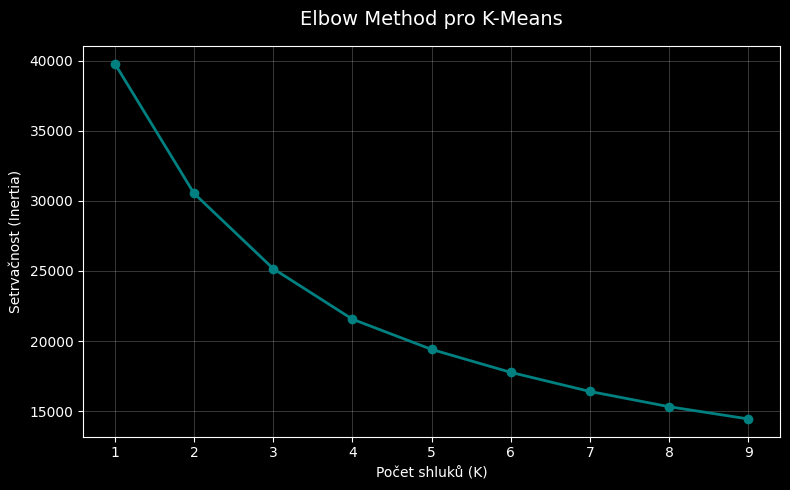

In [4]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='teal', linewidth=2)
plt.title('Elbow Method pro K-Means', color='white', fontsize=14, pad=15)
plt.xlabel('Počet shluků (K)', color='white')
plt.ylabel('Setrvačnost (Inertia)', color='white')
plt.xticks(K_range, color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- Hledání optimálního K pomocí Silhouette Score ---
Pro K=2 je Silhouette skóre: 0.343
Pro K=3 je Silhouette skóre: 0.369
Pro K=4 je Silhouette skóre: 0.270
Pro K=5 je Silhouette skóre: 0.210
Pro K=6 je Silhouette skóre: 0.197
Pro K=7 je Silhouette skóre: 0.189


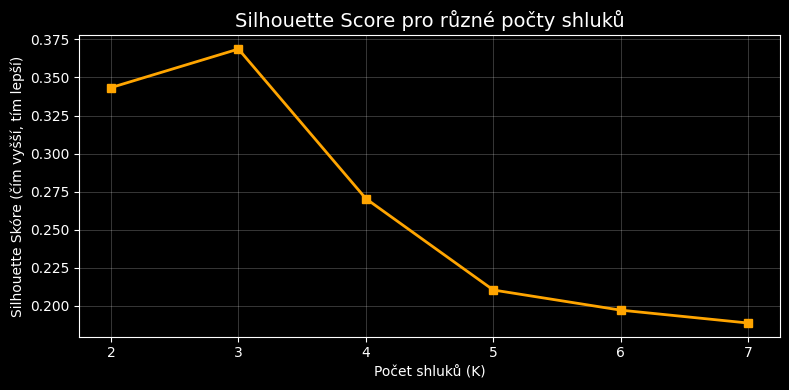

In [10]:
from sklearn.metrics import silhouette_score

print("\n--- Hledání optimálního K pomocí Silhouette Score ---")
silhouette_scores = []

# Měříme od K=2, protože pro 1 shluk nelze Silhouette spočítat
K_range_sil = range(2, 8)

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(X_cluster)

    # Výpočet skóre
    score = silhouette_score(X_cluster, cluster_labels)
    silhouette_scores.append(score)
    print(f"Pro K={k} je Silhouette skóre: {score:.3f}")

# Vykreslení
plt.figure(figsize=(8, 4))
plt.plot(K_range_sil, silhouette_scores, marker='s', color='orange', linewidth=2)
plt.title('Silhouette Score pro různé počty shluků', color='white', fontsize=14)
plt.xlabel('Počet shluků (K)', color='white')
plt.ylabel('Silhouette Skóre (čím vyšší, tím lepší)', color='white')
plt.xticks(K_range_sil, color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Na základě tohoto grafu by mělo jít lépe vidět, kde je lokální maximum (nejlepší K)

In [5]:
OPTIMAL_K = 3

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
X_cluster['Cluster'] = kmeans_final.fit_predict(X_cluster)

X_cluster['Dropout'] = y_all

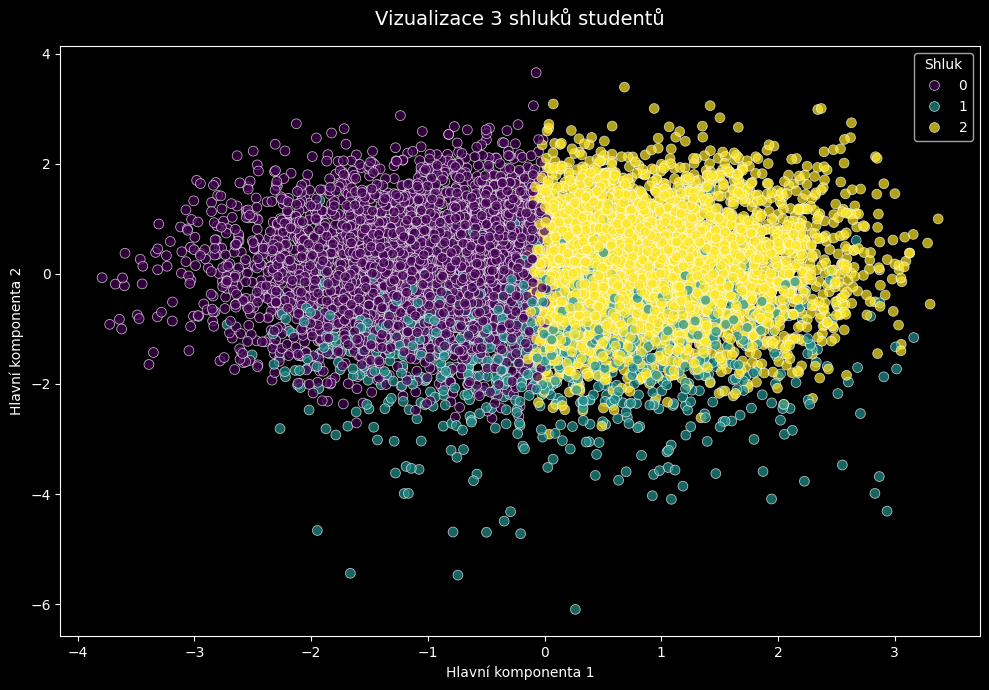

In [6]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_cluster[cols_for_clustering])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=components[:, 0], y=components[:, 1],
    hue=X_cluster['Cluster'],
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title(f'Vizualizace {OPTIMAL_K} shluků studentů', color='white', fontsize=14, pad=15)
plt.xlabel('Hlavní komponenta 1', color='white')
plt.ylabel('Hlavní komponenta 2', color='white')
plt.legend(title='Shluk')
plt.tight_layout()
plt.show()

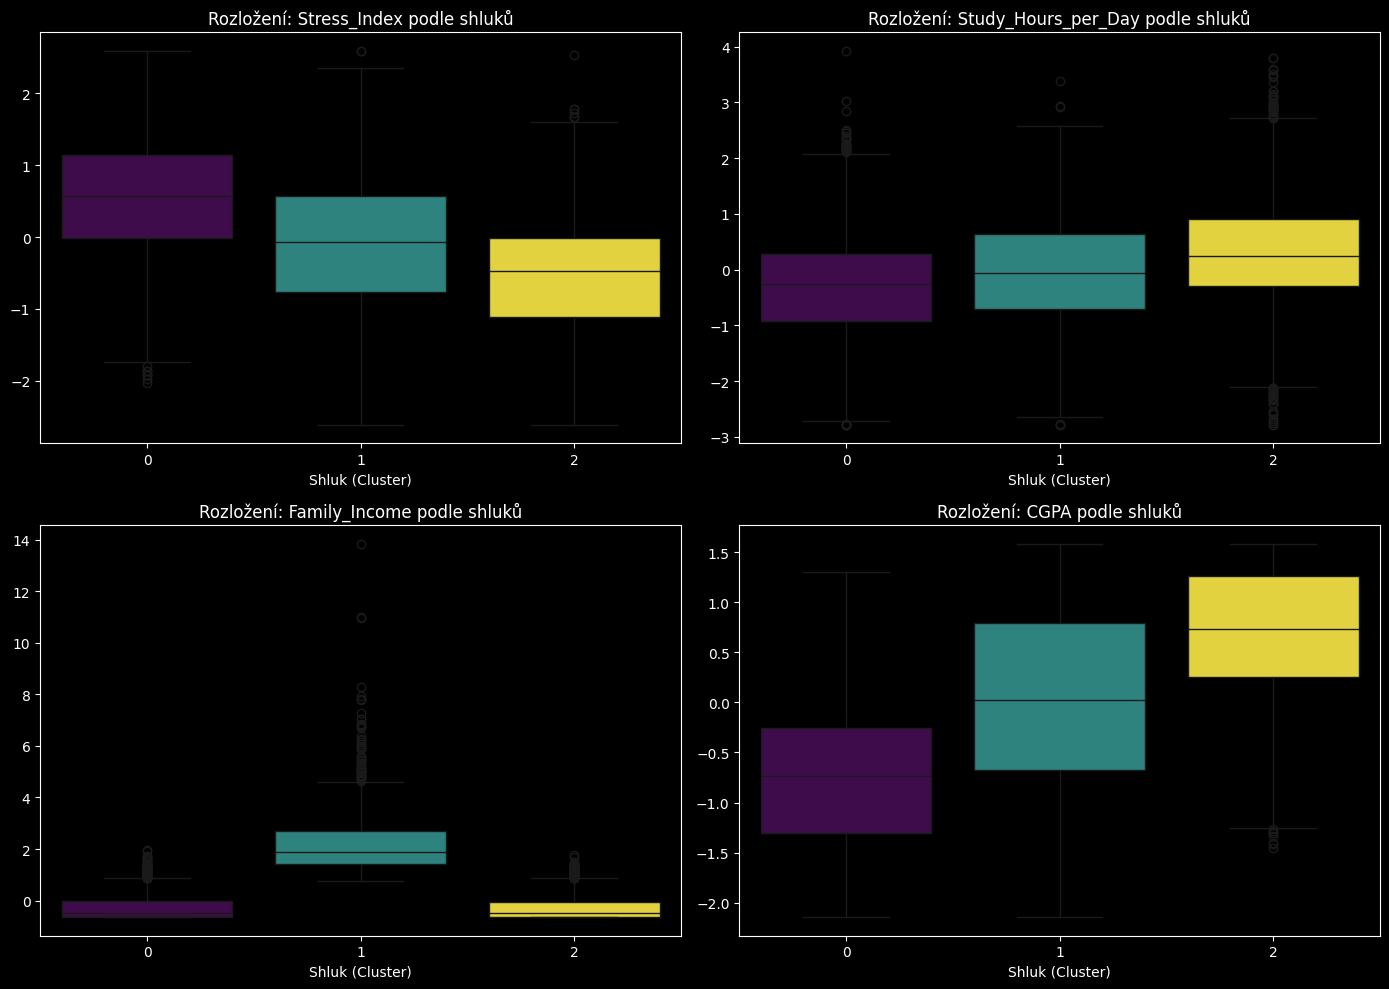

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Projdeme všechny sloupce, které jsme shlukovali
for i, col in enumerate(cols_for_clustering):
    # OPRAVA: Přidáno hue='Cluster' a legend=False
    sns.boxplot(data=X_cluster, x='Cluster', y=col, hue='Cluster', ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'Rozložení: {col} podle shluků', color='white', fontsize=12)
    axes[i].tick_params(colors='white')
    axes[i].set_xlabel('Shluk (Cluster)', color='white')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [8]:
print("\n--- Průměrné hodnoty pro každý shluk ---")
cluster_profiles = X_cluster.groupby('Cluster').mean()
print(cluster_profiles)


--- Průměrné hodnoty pro každý shluk ---
         Stress_Index  Study_Hours_per_Day  Family_Income      CGPA   Dropout
Cluster                                                                      
0            0.586967            -0.303972      -0.273405 -0.769427  0.399721
1           -0.108822            -0.030930       2.227619  0.027408  0.211242
2           -0.538245             0.287335      -0.273029  0.712426  0.087628
